Nome: Everton Romanzini Colombo

RA: 257234

Curso: Ciência da Computação



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [2]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [3]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [4]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

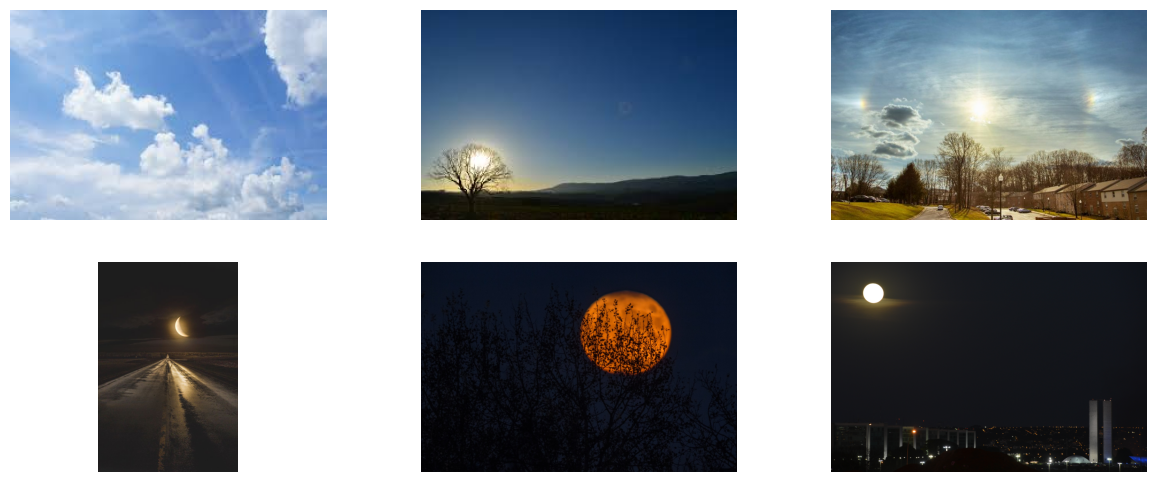

In [5]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:
  
  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

Hitogramas para a imagem 0:


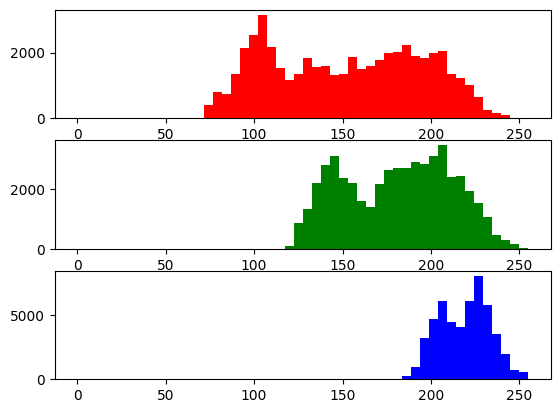

Hitogramas para a imagem 1:


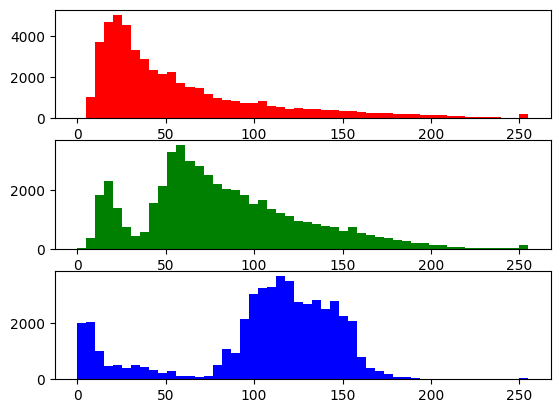

Hitogramas para a imagem 2:


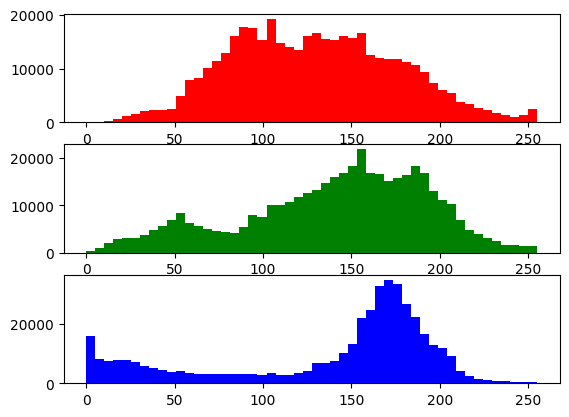

Hitogramas para a imagem 3:


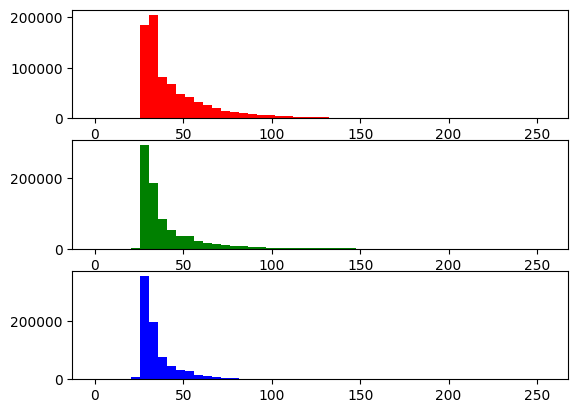

Hitogramas para a imagem 4:


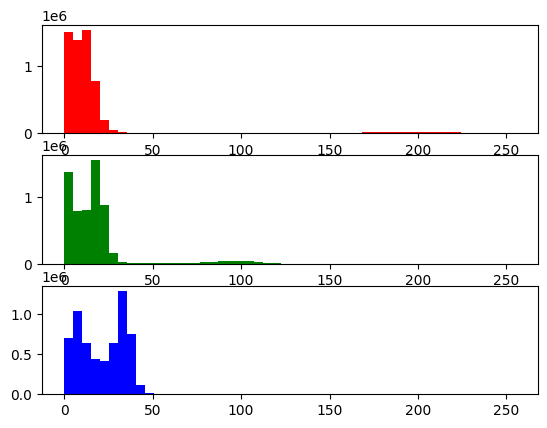

Hitogramas para a imagem 5:


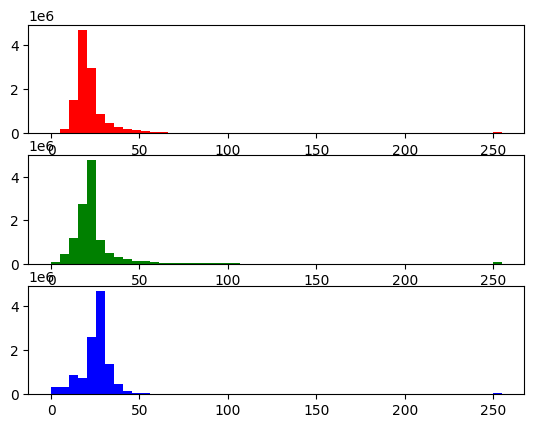

In [6]:
n_bins = 50

for i, img in enumerate(all_imgs):
    print(f"Hitogramas para a imagem {i}:")

    fig, axes = plt.subplots(3, 1)
    for channel, color in enumerate(['red', 'green', 'blue']):
        h, bin_edges = np.histogram(img[:, :, channel], n_bins, (0, 255))
        plt.sca(axes[channel])
        plota_hist(h, color, n_bins, bin_edges)
    plt.show()

**Discussão:** Sim, é possível distinguir se uma imagem foi tirada durante o dia ou à noite apenas pelos histogramas. Imagens diurnas têm histogramas mais bem distribuidos pelo eixo X, e com mais contagens nas porções mais à direita (i.e. pixels com maior intesidade, em razão da maior luminosidade). Em contrapartida, os histogramas das imagens noturnas mostram contagens mais concetradas nas porções à esquerda do eixo x (i.e. picos com menor intensidade, em razão da baixa luminosidade).

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

Imagens Orginais:


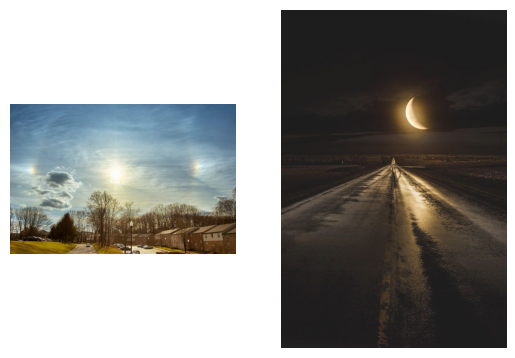


Média RGB


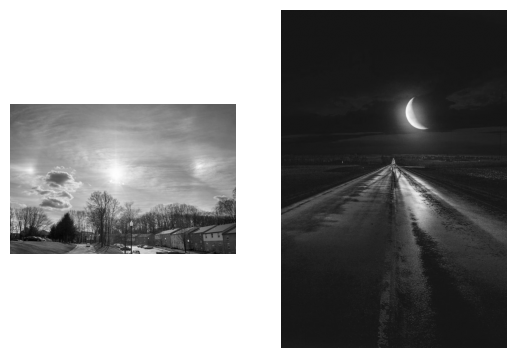

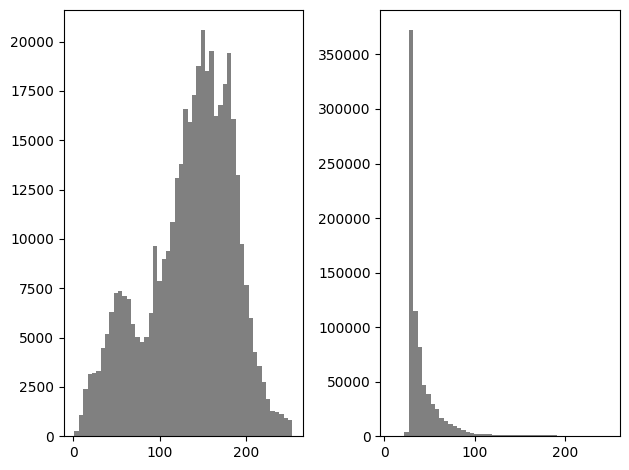


Média Ponderada


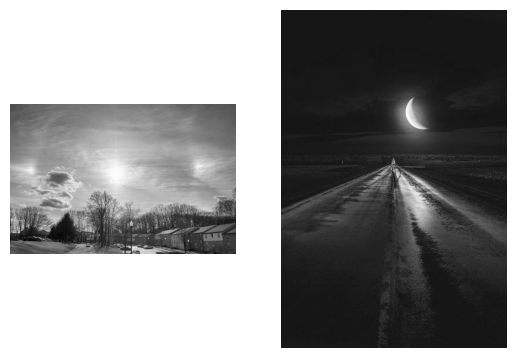

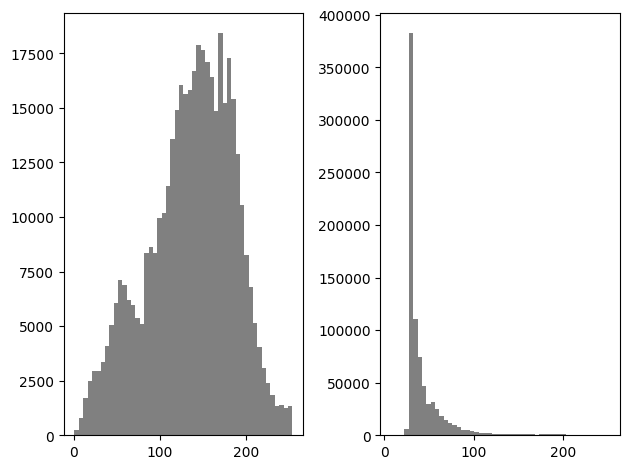


PIL


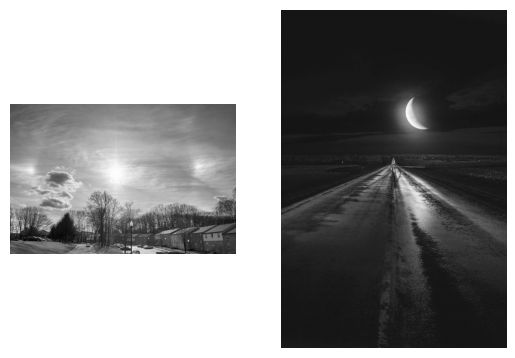

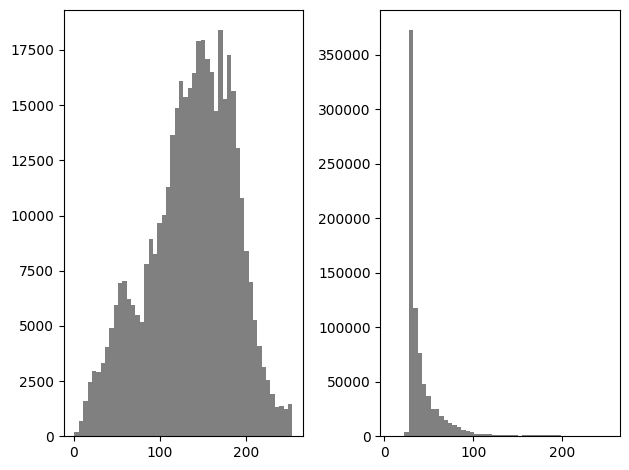

In [7]:
img_dia, img_noite = all_imgs[2], all_imgs[3]

def imshow_side_by_side(imgs, **plot_args):
    fig, axes = plt.subplots(1, len(imgs))
    for i, img in enumerate(imgs):
        axes[i].axis('off')
        axes[i].imshow(img, **plot_args)
    plt.show()

def plot_hists_side_by_side(imgs):
    fig, axes = plt.subplots(1, len(imgs))
    for i, img in enumerate(imgs):
        plt.sca(axes[i])
        h, bin_edges = np.histogram(img, n_bins)
        plota_hist(h, 'gray', n_bins, bin_edges)
    plt.tight_layout()
    plt.show()

print("Imagens Orginais:")
imshow_side_by_side([img_dia, img_noite])

print("\nMédia RGB")
mean_dia = np.mean(img_dia, axis=2)
mean_noite = np.mean(img_noite, axis=2)
imshow_side_by_side([mean_dia, mean_noite], cmap='gray')
plot_hists_side_by_side([mean_dia, mean_noite])

print("\nMédia Ponderada")
# gray = 0.299R + 0.587G + 0.114B
weights = (299/1000, 587/1000, 114/1000)
wavg_dia = np.average(img_dia, axis=2, weights=weights).astype(np.uint8)
wavg_noite = np.average(img_noite, axis=2, weights=weights).astype(np.uint8)
imshow_side_by_side([wavg_dia, wavg_noite], cmap='gray')
plot_hists_side_by_side([wavg_dia, wavg_noite])

print("\nPIL")
pil_dia = Image.fromarray(img_dia).convert("L")
pil_noite = Image.fromarray(img_noite).convert("L")
imshow_side_by_side([pil_dia, pil_noite], cmap='gray')
plot_hists_side_by_side([pil_dia, pil_noite])

**Discussão:** Os três histogrmas têm formatos gerais bem semelhantes (ao menos para as imagens selecionadas). Nota-se que o histograma da média simples é o mais distinto dos outros dois. Curiosamente, o histograma da média ponderada e o do PIL não são identicos como esperava-se: são bem semelhantes, mas levemente diferentes. Após alguma análise, atribui-se esse comportamento a imprecisões numéricas.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [8]:
def histstat(f):
    
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [9]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [10]:
f = all_imgs[3]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

43.47
704.20
3.65
16.82
28.00
29.00
33.00
69.00
179.00


**Discussão:** Sim, parecem ser suficientemente diferentes. A média, a variância e todos os percentis, são consideravelmente menores, enquanto skewness e kurtosis são maiores. Apesar da necessidade de visualização de mais exemplos para confirmação, estes resultados estão de acordo com as observações registradas na discussão do exercício 1.1

## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

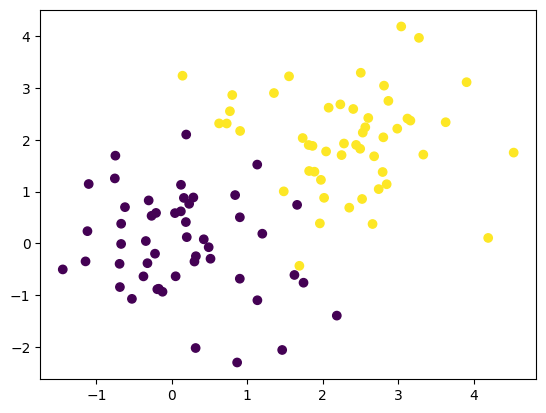

In [11]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



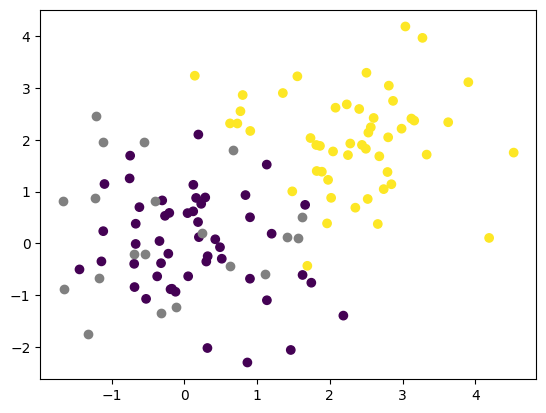

In [12]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [13]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


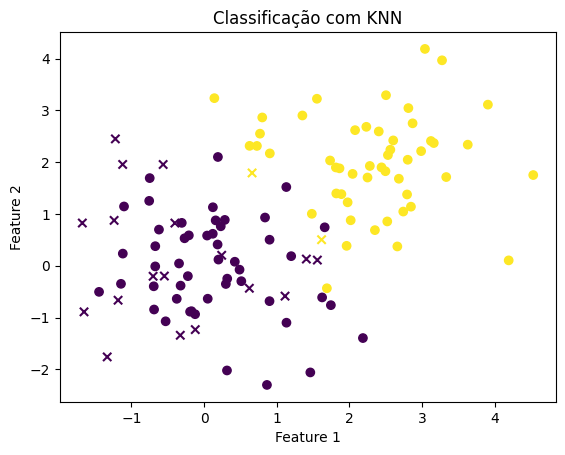

In [14]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [15]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [16]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [17]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

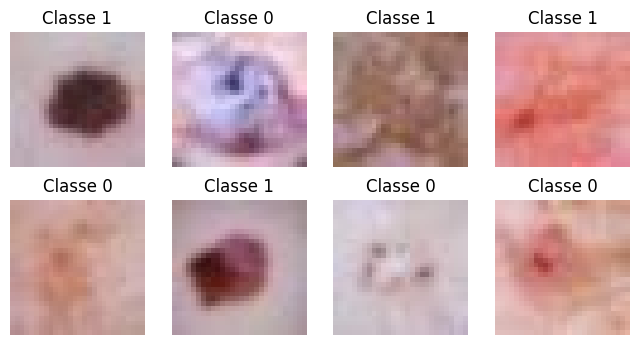

In [18]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [19]:
def extract_features(rgb_imgs: list[np.ndarray]) -> np.ndarray:
    features = []
    for img in rgb_imgs:
        gray_img = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
        features.append(histstat(gray_img))
    
    return np.array(features)

features_train = extract_features(images_train)
features_test = extract_features(images_test)

print(features_train.shape, features_test.shape)

(400, 9) (100, 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


In [47]:
my_world_dominating_ai = KNeighborsClassifier(n_neighbors=8)
my_world_dominating_ai.fit(features_train, labels_train)

y_pred_train = my_world_dominating_ai.predict(features_train)
y_pred = my_world_dominating_ai.predict(features_test)

print("Métricas de treino:")
print(f"\tAcurácia:\t{accuracy_score(y_pred_train, labels_train):.2f}")
print(f"\tPrecisão:\t{precision_score(y_pred_train, labels_train):.2f}")
print(f"\tRecall:\t\t{recall_score(y_pred_train, labels_train):.2f}")
print(f"\tF1-Score:\t{f1_score(y_pred_train, labels_train):.2f}")
print("Matriz de confusão")
print(confusion_matrix(y_pred_train, labels_train))

print("\nMétricas de teste:")
print(f"\tAcurácia:\t{accuracy_score(y_pred, labels_test):.2f}")
print(f"\tPrecisão:\t{precision_score(y_pred, labels_test):.2f}")
print(f"\tRecall:\t\t{recall_score(y_pred, labels_test):.2f}")
print(f"\tF1-Score:\t{f1_score(y_pred, labels_test):.2f}")

print("Matriz de confusão")
print(confusion_matrix(y_pred, labels_test))

Métricas de treino:
	Acurácia:	0.80
	Precisão:	0.79
	Recall:		0.81
	F1-Score:	0.80
Matriz de confusão
[[162  42]
 [ 38 158]]

Métricas de teste:
	Acurácia:	0.82
	Precisão:	0.82
	Recall:		0.82
	F1-Score:	0.82
Matriz de confusão
[[41  9]
 [ 9 41]]


**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

In [21]:
def plot_knn_data_landscape_2d(features_train, labels_train, features_test, labels_test_pred, dimensions=(0,1)):
    plt.scatter(features_train[:, dimensions[0]], features_train[:, dimensions[1]], c=labels_train)
    plt.scatter(features_test[:, dimensions[0]], features_test[:, dimensions[1]], marker='x', c=labels_test_pred)
    plt.title(f'Classificação com KNN, atributos {dimensions[1]} x {dimensions[0]}')
    plt.xlabel(f'Feature {dimensions[0]}')
    plt.ylabel(f'Feature {dimensions[1]}')
    plt.show()

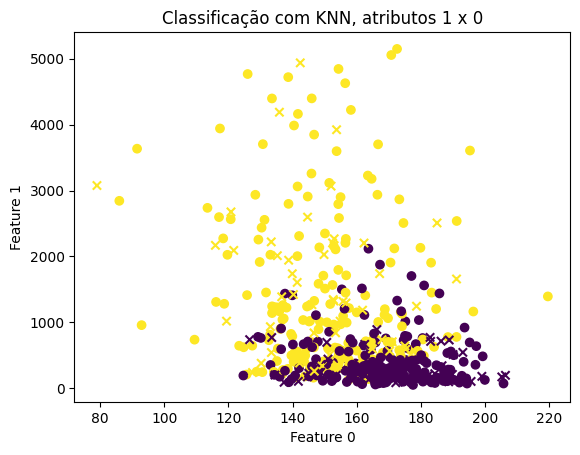

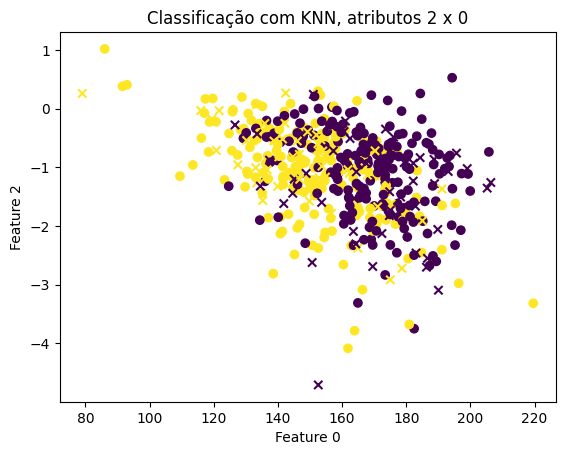

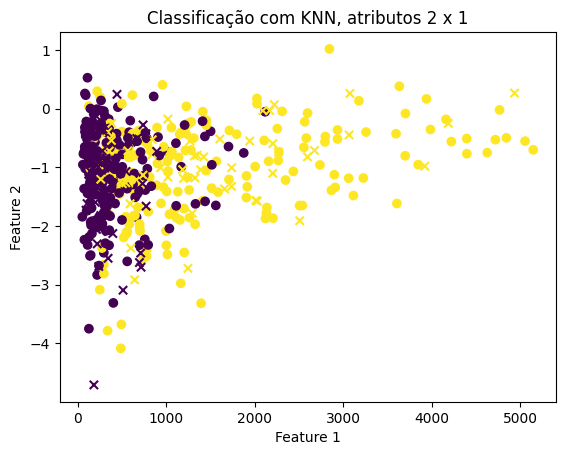

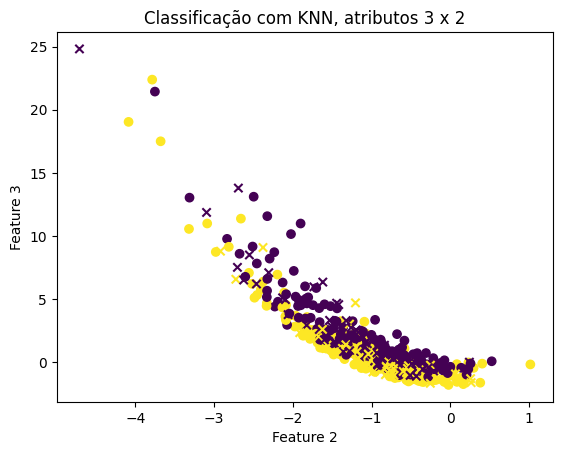

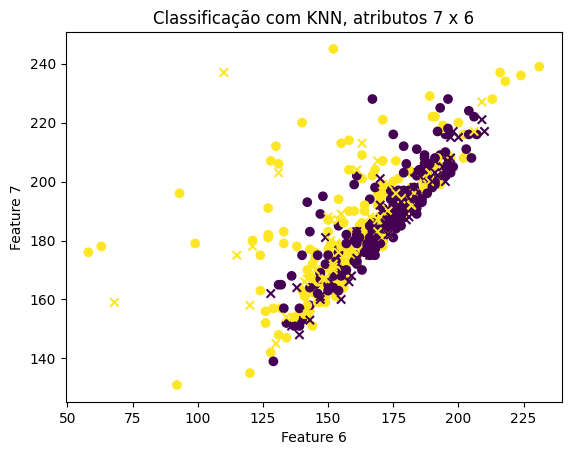

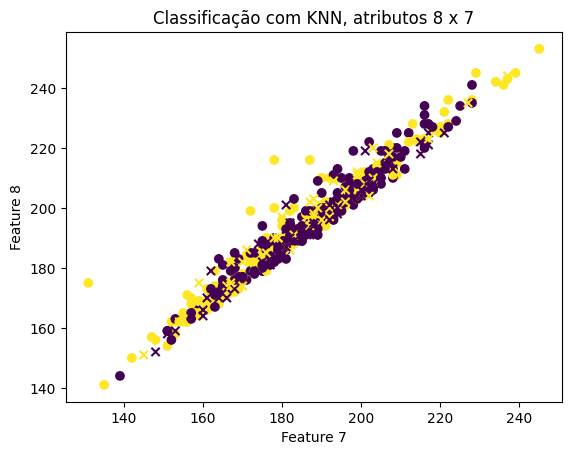

In [22]:
dimension_pairs = [(0, 1), (0, 2), (1, 2), (2, 3), (6, 7), (7, 8)]

for dims in dimension_pairs:
    plot_knn_data_landscape_2d(
        features_train, labels_train,
        features_test, y_pred,
        dimensions=dims
    )

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

Resposta: Eu particularmente não gostaria que meu exame oncológico dependesse de um modelo que erra por volta de 20% das vezes. Dito isso, para um modelo simples operando em dados puramente radiométricos, me surpreendi com a acurácia. Em meu caso, os dois tipos de erros (falso positivo e falso negativo) aconteceram com a mesma frequência no conjunto de teste. Possíveis modificações que vejo são: normalizar os dados, utilizar as informações das bandas de cores individualmente.

Não vejo nenhuma divisória clara entre as classes nos scatter plots.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

In [71]:
from sklearn.feature_selection import SelectKBest, f_classif

# Redimensionando:
images_resized_train = [np.array(Image.fromarray(image).resize((14, 14), resample=Image.BILINEAR)) for image in images_train]
images_resized_test = [np.array(Image.fromarray(image).resize((14, 14), resample=Image.BILINEAR)) for image in images_test]

features_resized_train = extract_features(images_resized_train)
features_resized_test = extract_features(images_resized_test)

# Selecionando features
selector = SelectKBest(f_classif, k=5)
features_resized_train_sel = selector.fit_transform(features_resized_train, labels_train)
features_resized_test_sel = selector.transform(features_resized_test)

print("Features originais:", features_resized_train.shape[1])
print("Features selecionadas:", features_resized_train_sel.shape[1])
print("Shape treino (selecionado):", features_resized_train_sel.shape)
print("Shape teste (selecionado):", features_resized_test_sel.shape)

Features originais: 9
Features selecionadas: 5
Shape treino (selecionado): (400, 5)
Shape teste (selecionado): (100, 5)


In [70]:
different_world_dominating_ai = KNeighborsClassifier(n_neighbors=5) # Menos vizinhos
different_world_dominating_ai.fit(features_resized_train_sel, labels_train)
y_pred_new = different_world_dominating_ai.predict(features_resized_test_sel)

print("\nMétricas de teste (com imagens redimensionadas, features selecionadas e número diferente de vizinhos):")
print(f"\tAcurácia:\t{accuracy_score(y_pred_new, labels_test):.2f}")
print(f"\tPrecisão:\t{precision_score(y_pred_new, labels_test):.2f}")
print(f"\tRecall:\t\t{recall_score(y_pred_new, labels_test):.2f}")
print(f"\tF1-Score:\t{f1_score(y_pred_new, labels_test):.2f}")
print("Matriz de confusão")
print(confusion_matrix(y_pred_new, labels_test))


Métricas de teste (com imagens redimensionadas, features selecionadas e número diferente de vizinhos):
	Acurácia:	0.83
	Precisão:	0.90
	Recall:		0.79
	F1-Score:	0.84
Matriz de confusão
[[38  5]
 [12 45]]


**Discussão:** O redimensionamento foi feito com Image.resize do PIL, e a seleção de feaures foi feita seguindo o item 1.13.2 da documentação do link. O número de vizinhos foi reduzido de 8 para 5. O resultado foi um considerável aumento de precisão (0.82 para 0.90), pequenos aumentos de acurácia e F1, e uma pequena redução de Recall. A matriz de confusão indica um aumento na proporção de erro correspondente a falsos negativos.

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [137]:
# Seu código aqui

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [146]:
# Seu código aqui